## Exploración inicial de los datos

En este notebook se realizará el análisis descriptivo de cada variable presente en el conjunto de datos `temporada1.parquet`.

La base de datos contiene información detallada sobre los lanzamientos realizados durante una temporada de béisbol profesional. Las variables registradas incluyen características del lanzamiento, información sobre el bateador y el pitcher, así como mediciones espaciales obtenidas mediante el sistema Statcast, las cuales permiten estudiar el comportamiento y la ubicación de la pelota durante el juego.

| Variable | Descripción |
|-----------|-------------|
| `pitch_id` | Identificador único de cada lanzamiento. |
| `release_speed` | Velocidad del lanzamiento al momento de salir de la mano del pitcher, medida en millas por hora (mph). |
| `batter` | Identificador del bateador asociado al lanzamiento. |
| `pitcher` | Identificador del pitcher que realiza el lanzamiento. |
| `description` | Descripción del resultado del lanzamiento. |
| `stand` | Lado del plato en el que se ubica el bateador (`L`: izquierdo, `R`: derecho). |
| `p_throws` | Mano con la que realiza el lanzamiento el pitcher (`L`: izquierda, `R`: derecha). |
| `pitch_type` | Tipo de lanzamiento clasificado por Statcast. |
| `balls` | Cantidad de bolas en la cuenta antes del lanzamiento. |
| `strikes` | Cantidad de strikes en la cuenta antes del lanzamiento. |
| `pfx_x` | Movimiento horizontal de la pelota, medido en pies desde la perspectiva del catcher. |
| `pfx_z` | Movimiento vertical de la pelota, medido en pies desde la perspectiva del catcher. |
| `plate_x` | Posición horizontal de la pelota al cruzar el home plate, desde la perspectiva del catcher. |
| `plate_z` | Posición vertical de la pelota al cruzar el home plate, desde la perspectiva del catcher. |
| `sz_top` | Límite superior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate. |
| `sz_bot` | Límite inferior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate. |



El objetivo de esta etapa es conocer la estructura y las características generales de los datos, identificar posibles valores faltantes o inconsistencias y obtener una primera aproximación a la distribución de las variables de interés.

In [1]:
# Cargamos los paquetes necesarios ACORDARNOS DE HACER EL AMBIENTE VIRTUAL
import matplotlib.pyplot as plt 
import polars as pl
import seaborn as sns

import pyprojroot

from plotnine import *

In [2]:
# Definir la ruta raiz del proyecto
ROOT = pyprojroot.here()

# Cargamos los datos
datos_entrenamiento= pl.read_parquet(ROOT / "datos" / "temporada1_original.parquet")
datos_validacion = pl.read_parquet(ROOT / "datos" / "temporada2_original.parquet")

Un aspecto importante a considerar es que las variables `pitch_id`, `batter` y `pitcher` se excluyen del análisis debido a que actúan únicamente como identificadores del lanzamiento y de los jugadores involucrados. En consecuencia, no contienen información con capacidad predictiva sobre la realización de un swing y su inclusión podría introducir ruido en el modelo.

In [3]:
datos_entrenamiento = datos_entrenamiento.drop(
    "pitch_id",
    "batter",
    "pitcher"
)

datos_validacion = datos_validacion.drop(
    "pitch_id",
    "batter",
    "pitcher"
)

Completada la carga de los datos, se visualizan las primeras 10 filas del conjunto de datos. Posteriormente, se procede a explorar sus características generales.

In [4]:
datos_entrenamiento.head(10)

release_speed,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
f64,str,str,str,str,i64,i64,f64,f64,f64,f64,f64,f64
93.800003,"""ball""","""R""","""R""","""SI""",1,1,-0.98,0.72,-1.23,4.1,3.7,1.82
95.599998,"""foul""","""R""","""R""","""FF""",3,2,-0.38,0.96,-0.45,3.1,3.41,1.56
94.800003,"""foul""","""R""","""R""","""FF""",1,0,-0.62,1.16,0.31,2.4,3.41,1.56
87.300003,"""ball""","""R""","""R""","""SL""",2,1,0.82,-0.06,1.11,2.21,3.7,1.73
98.599998,"""called_strike""","""R""","""R""","""FF""",3,1,-0.33,0.95,-0.35,3.39,3.7,1.7
98.900002,"""foul""","""R""","""R""","""FF""",3,2,-0.42,0.89,-0.75,2.76,3.41,1.56
95.400002,"""foul""","""R""","""R""","""FF""",0,0,-0.58,0.98,-0.16,2.36,3.41,1.56
87.400002,"""ball""","""R""","""R""","""SL""",0,1,0.24,0.15,-0.25,3.97,3.61,1.79
87.199997,"""called_strike""","""R""","""R""","""SL""",2,1,0.16,0.24,-0.54,3.09,3.64,1.7


### Análisis Univariado

A continuación, se presenta el análisis univariado de las variables presentes en la base de datos, describiendo sus principales características.

#### Variables cuantitativas

En primer lugar, se analizan las variables cuantitativas de la base de datos. Para ello, se calculan medidas descriptivas de tendencia central, dispersión y posición, tales como la media, mediana, desvío estándar, cuartiles, máximo y mínimo. 

In [6]:
# Se seleccionan las variables cuantitativas del conjunto de datos
variables_cuantitativas = datos_entrenamiento.select([
    "release_speed",
    "balls",
    "strikes",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot"
])

# Se arma una tabla resumen, la cual presenta las medidas descriptivas para cada variable cuantitativa
tabla_resumen = variables_cuantitativas.describe()

# Se renombran las medidas descriptivas
tabla_resumen = tabla_resumen.with_columns(
    pl.col("statistic").replace({
        "count": "Cantidad",
        "null_count": "Nulos",
        "mean": "Media",
        "std": "Desvío",
        "min": "Mínimo",
        "25%": "Q1",
        "50%": "Mediana",
        "75%": "Q3",
        "max": "Máximo"
    })
)

tabla_resumen = tabla_resumen.rename({
    "statistic": "Medida"
})

# Se muestra la tabla resumen
tabla_resumen


Medida,release_speed,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Cantidad""",709485.0,709852.0,709852.0,706819.0,708792.0,709485.0,709452.0,709485.0,709440.0
"""Nulos""",367.0,0.0,0.0,3033.0,1060.0,367.0,400.0,367.0,412.0
"""Media""",88.848689,0.883648,0.895387,-0.10355,0.65788,0.043603,2.275044,3.391976,1.57385
"""Desvío""",6.050308,0.968486,0.828389,0.866855,0.747155,0.846102,0.984652,0.164649,0.089665
"""Mínimo""",30.1,0.0,0.0,-2.56,-2.13,-6.1,-5.07,2.5,0.77
"""Q1""",84.599998,0.0,0.0,-0.83,0.2,-0.53,1.64,3.3,1.51
"""Mediana""",89.900002,1.0,1.0,-0.17,0.76,0.04,2.28,3.41,1.56
"""Q3""",93.699997,2.0,2.0,0.59,1.28,0.61,2.92,3.49,1.62
"""Máximo""",103.400002,4.0,2.0,2.84,2.58,9.11,9.39,4.47,2.26


La base analizada contiene aproximadamente 710000 lanzamientos y presenta una cantidad pequeña de valores faltantes en comparación al total de observaciones. En particular, las variables `balls` y `strikes` son las únicas variables cuantitativas que no registran datos faltantes, mientras que `pfx_x` es la variable con mayor cantidad de valores nulos.

Respecto de la velocidad de lanzamiento (`release_speed`), la media es de 88,85 mph y la mediana de 89,9 mph. Además, la mitad de los lanzamientos presenta velocidades entre 84,6 y 93,7 mph, por lo que la mayor parte de las observaciones se concentra alrededor de las 90 mph.

Las variables `balls` y `strikes` presentan medianas iguales a 1. Asimismo, el 75% de los lanzamientos ocurre con dos bolas o menos y con dos strikes o menos, lo que muestra que gran parte de las observaciones corresponde a conteos bajos.

Por otro lado, las variables asociadas al movimiento y la ubicación de la pelota (`pfx_x`, `pfx_z`, `plate_x` y `plate_z`) presentan una mayor variabilidad. Por ejemplo, `plate_x` toma valores entre -6,1 y 9,11, mientras que `plate_z` varía entre -5,07 y 9,39. En contraste, los límites de la zona de strike presentan menor variabilidad: `sz_top` tiene una media de 3,39 pies y `sz_bot` una media de 1,57 pies, con desvíos estándar de 0,16 y 0,09 respectivamente.

Para complementar estas medidas descriptivas, se incorporan histogramas de cada variable contínua, permitiendo observar de forma más clara cómo se distribuyen los datos.

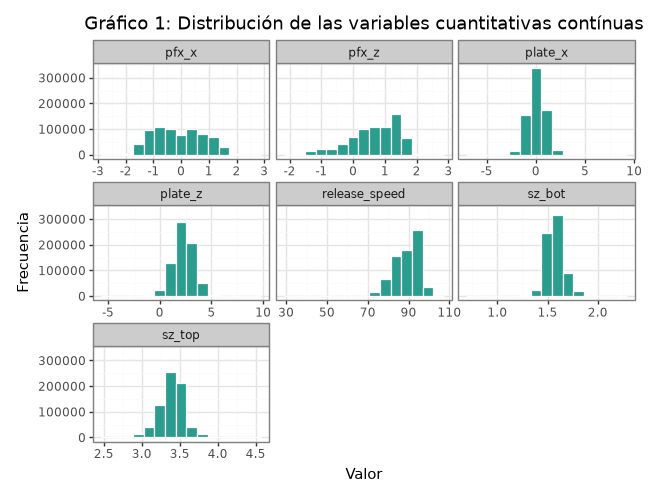

In [7]:
# Se seleccionan las variables continuas
datos_continuos = variables_cuantitativas.drop(["balls", "strikes"])

# 
datos_long = (
    datos_continuos
    .to_pandas()
    .melt(
        var_name="Variable",
        value_name="Valor"
    )
    .dropna()
)

# Panel de gráficos para las variables cuantitativas continuas
(
    ggplot(datos_long, aes(x="Valor"))
    + geom_histogram(
        bins=15,
        fill="#2A9D8F",
        color="white"
    )
    + facet_wrap("~Variable", scales = "free_x")
    + labs(
        title="Gráfico 1: Distribución de las variables cuantitativas contínuas",
        x="Valor",
        y="Frecuencia"
    )
    + theme_bw()
)

Del panel de gráficos anterior se observa que las variables asociadas a la ubicación de la zona de strike, como `plate_x`, `plate_z`, `sz_bot` y `sz_top`, presentan distribuciones aproximadamente simétricas. En particular, las variables `sz_bot` y `sz_top` presentan menor variabilidad, mientras que `plate_x` y `plate_z` muestran una mayor dispersión en sus valores.

Por otro lado, la variable `release_speed` presenta una asimetría hacia la izquierda. Si bien la cercanía entre la media y la mediana sugería inicialmente una distribución aproximadamente simétrica, el histograma permite identificar una desviación respecto de dicho comportamiento.

La variable `pfx_z` también presenta una asimetría hacia la izquierda, junto con la presencia de algunas observaciones alejadas del resto de los datos.

Finalmente, la variable `pfx_x` presenta una distribución aproximadamente simétrica, aunque con una mayor dispersión en comparación con las variables relacionadas con la ubicación de la zona de strike.

Debido a que las variables presentan diferentes escalas de medición, los histogramas permiten analizar la forma de cada distribución de manera individual, pero no comparar directamente sus magnitudes. Si bien una estandarización permitiría llevar las variables a una escala común, esta transformación no modifica la forma de las distribuciones, por lo que no aporta información adicional para el análisis descriptivo realizado.

Al igual que para las variables cuantitativas continuas, se realiza un análisis descriptivo de las variables cuantitativas discretas (`balls` y `strikes`), con el objetivo de estudiar su comportamiento dentro del conjunto de datos.

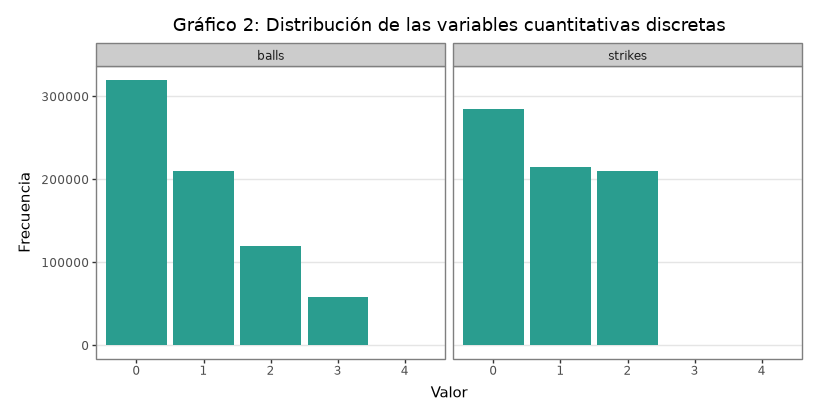

In [8]:
# Se seleccionan las variables discretas 
datos_discretos = (
    variables_cuantitativas
    .select(["balls", "strikes"])
    .to_pandas()
    .melt(
        var_name="Variable",
        value_name="Valor"
    )
    .dropna()
)

# Panel de gráficos para las variables cuantitativas discretas
(
    ggplot(datos_discretos,
           aes(x="factor(Valor)"))
    + geom_bar(fill="#2A9D8F")
    + facet_wrap("~Variable")
    + labs(
        title="Gráfico 2: Distribución de las variables cuantitativas discretas",
        x="Valor",
        y="Frecuencia"
    )
    + theme_bw()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor=element_blank()
    )
)

A partir de los gráficos de barras se observa que ambas variables presentan una mayor proporción de observaciones asociadas a los valores más bajos.

En particular, la variable correspondiente a la cantidad de bolas en la cuenta antes del lanzamiento (`balls`) muestra que la frecuencia disminuye a medida que aumenta el número de bolas acumuladas, siendo el valor 0 el que presenta mayor cantidad de registros.

Por otro lado, la variable asociada a la cantidad de strikes en la cuenta antes del lanzamiento (`strikes`) también presenta una mayor frecuencia para el valor 0. Sin embargo, los valores 1 y 2 muestran una cantidad de observaciones similar, sin evidenciar diferencias marcadas entre ambos.


#### Variables cualitativas

Para las variables cualitativas se examinó la distribución de frecuencias de cada categoría mediante tablas y representaciones gráficas. Esto permite obtener una visión general de la composición de la muestra y de la frecuencia relativa de cada nivel observado.

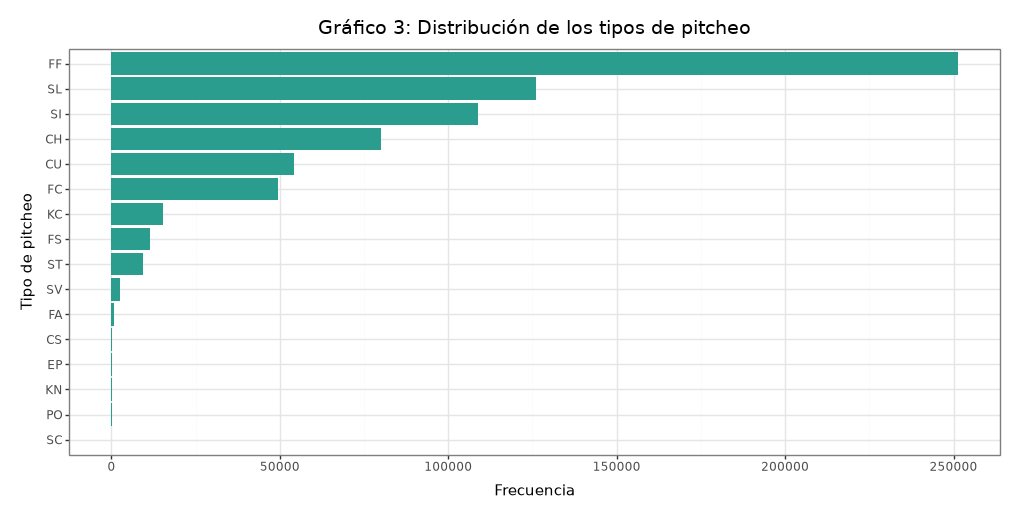

In [9]:
# Se filtra la variable tipo de pitcheo
freq_pitch = (
    datos_entrenamiento
    .filter(pl.col("pitch_type").is_not_null())
    .group_by("pitch_type")
    .len()
    .sort("len", descending=True)
    .to_pandas()
)

# Se arma el gráfico de barras horizontales
(
    ggplot(freq_pitch,
           aes(x="pitch_type", y="len"))
    + geom_col(fill="#2A9D8F")
    + coord_flip()
    + scale_x_discrete(limits=freq_pitch["pitch_type"].tolist()[::-1])
    + labs(
        title="Gráfico 3: Distribución de los tipos de pitcheo",
        x="Tipo de pitcheo",
        y="Frecuencia"
    )
    + theme_bw()
    + theme(
        figure_size=(10, 5),
        plot_title=element_text(size=14)
    )
)

En el gráfico se observa que las categorías del tipo de pitcheo (`pitch_type`) presentan frecuencias muy diferentes entre sí. Los tipos de lanzamiento `FF`, `SI` y `SL` son los que concentran la mayor cantidad de observaciones, sugiriendo que son los lanzamientos más utilizados. En cambio, el resto de las categorías aparecen con una frecuencia considerablemente menor dentro del conjunto de datos, lo que indicaría que corresponden a situaciones menos frecuentes dentro del juego.


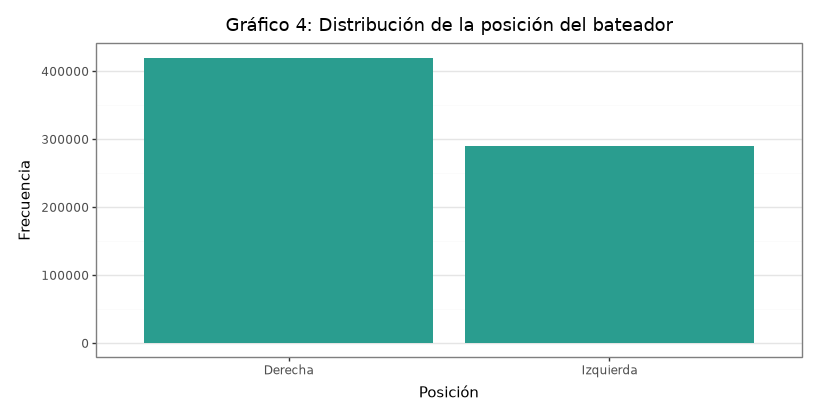

In [10]:
# Se filtra la variable posición del bateador
freq_stand = (
    datos_entrenamiento
    .filter(pl.col("stand").is_not_null())
    .group_by("stand")
    .len()
    .sort("stand")
    .to_pandas()
)

# Se renombran las categorias solo para el gráfico
freq_stand["stand"] = freq_stand["stand"].replace({
    "L": "Izquierda",
    "R": "Derecha"
})

# Se arma el gráfico
(
    ggplot(freq_stand,
           aes(x="stand", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Gráfico 4: Distribución de la posición del bateador",
        x="Posición",
        y="Frecuencia"
    )
    + theme_bw()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank()
    )
)

En cuanto a la variable posición de bateo (`stand`), se observa una mayor presencia de jugadores que batean desde la derecha en comparación con aquellos que lo hacen desde la izquierda.

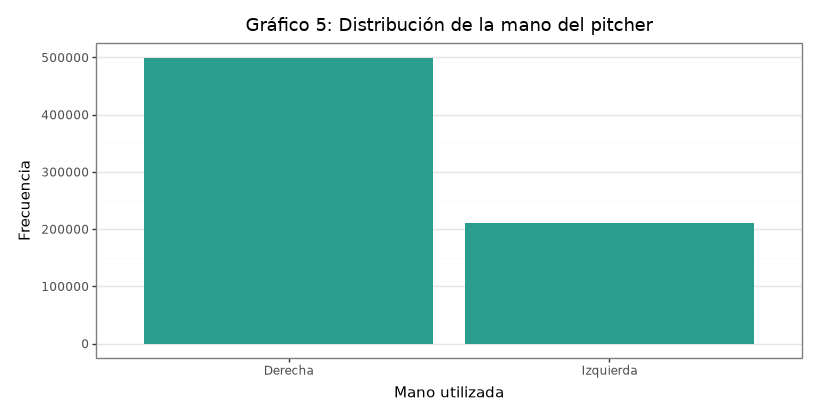

In [11]:
# Se filtra la variable mano del pitcher
freq_throws = (
    datos_entrenamiento
    .filter(pl.col("p_throws").is_not_null())
    .group_by("p_throws")
    .len()
    .sort("p_throws")
    .to_pandas()
)

# Se renombran las categorias solo para el gráfico
freq_throws["p_throws"] = freq_throws["p_throws"].replace({
    "L": "Izquierda",
    "R": "Derecha"
})

# Se arma el gráfico
(
    ggplot(freq_throws,
           aes(x="p_throws", y="len"))
    + geom_col(fill="#2A9D8F")
    + labs(
        title="Gráfico 5: Distribución de la mano del pitcher",
        x="Mano utilizada",
        y="Frecuencia"
    )
    + theme_bw()
    + theme(
        figure_size=(8, 4),
        panel_grid_major_x=element_blank(),
        panel_grid_minor_x=element_blank()
    )
)

En cuanto a la variable mano del pitcher (`p_throws`), se observa una mayor presencia de lanzadores diestros en comparación con aquellos que realizan sus lanzamientos con la mano izquierda.

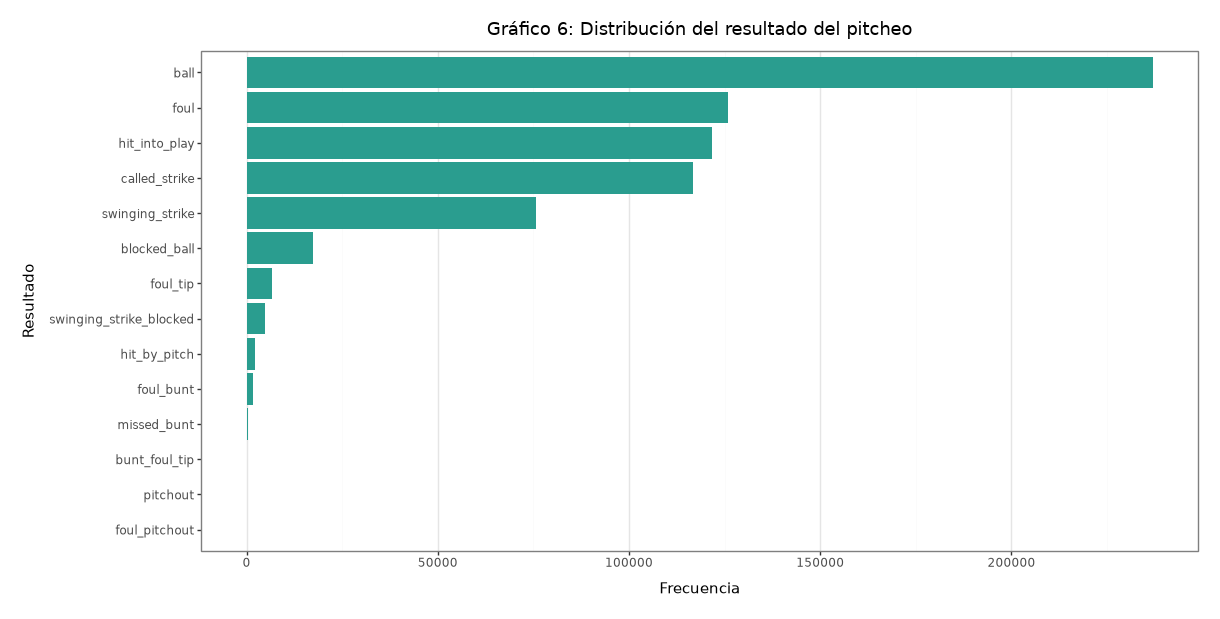

In [12]:
# Se filtra la variable resultado del pitcheo
freq_description = (
    datos_entrenamiento
    .filter(pl.col("description").is_not_null())
    .group_by("description")
    .len()
    .sort("len", descending=True)
    .to_pandas()
)

# Se arma el gráfico
(
    ggplot(
        freq_description,
        aes(x="description", y="len")
    )
    + geom_col(fill="#2A9D8F")
    + coord_flip()
    + scale_x_discrete(
        limits=freq_description["description"].tolist()[::-1]
    )
    + labs(
        title="Gráfico 6: Distribución del resultado del pitcheo",
        x="Resultado",
        y="Frecuencia"
    )
    + theme_bw()
    + theme(
        figure_size=(12, 6),
        panel_grid_major_y=element_blank(),
        panel_grid_minor_y=element_blank()
    )
)

Para la variable resultado del pitcheo (`description`), se observa que la categoría `ball` es la que presenta la mayor frecuencia dentro del conjunto de datos. Le siguen `foul`, `hit_into_play` y `called_strike`, mientras que el resto de los resultados tienen una cantidad de observaciones mucho menor.


### Análisis Bivariado entre las variables explicativas

Con el fin de profundizar en la comprensión de los datos, se realizó un análisis bivariado entre las variables más relevantes de la base. 

Este análisis permitió evaluar posibles asociaciones y patrones de comportamiento entre las características de los lanzamientos y sus resultados, aportando información útil para la selección de variables y el desarrollo de modelos predictivos posteriores.

Con el objetivo de explorar las relaciones lineales entre las variables numéricas, se calculó una matriz de correlación. Su análisis permite identificar asociaciones significativas entre variables y detectar posibles redundancias que podrían influir en etapas posteriores del estudio.

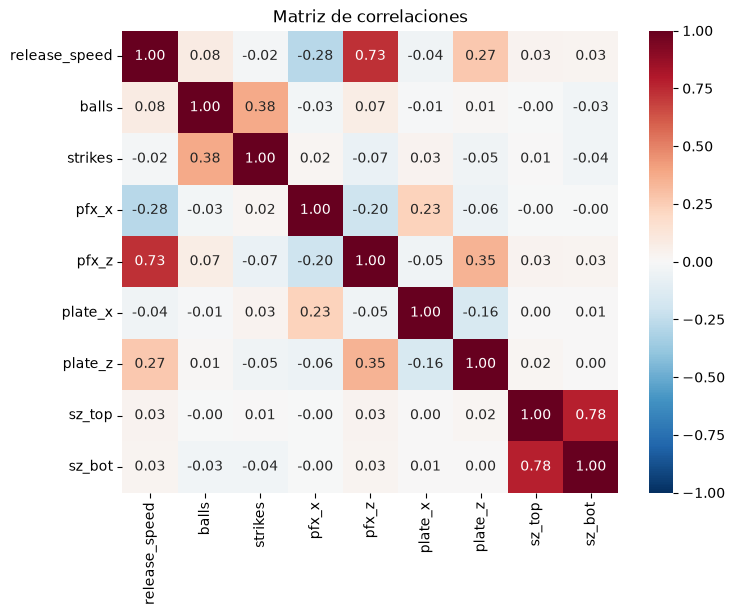

In [13]:
# Eliminar filas con algún valor nulo
corr_matrix = (
    variables_cuantitativas
    .drop_nulls()
    .to_pandas()
    .corr()
)

# Matriz de correlaciones
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Matriz de correlaciones")
plt.show()

La matriz de correlaciones permite observar que la mayoría de las variables presentan asociaciones lineales débiles entre sí. Sin embargo, se destacan algunas relaciones de mayor intensidad.
 
En particular, `release_speed` y `pfx_z` presentan una correlación positiva alta (r = 0.73), indicando que mayores velocidades de lanzamiento tienden a asociarse con mayores valores de movimiento vertical inducido.

Además, las variables `sz_top` y `sz_bot` presentan una correlación positiva alta (r = 0.78), lo cual resulta esperable dado que ambas representan los límites superior e inferior de la zona de strike, respectivamente. Por este motivo, no se construye un gráfico de dispersión para visualizar la relación entre estas.

A partir de lo analizado anteriormente, se procede a construir un gráfico de dispersión que permita visualizar la relación existente entre la velocidad de lanzamiento y el movimiento vertical inducido.

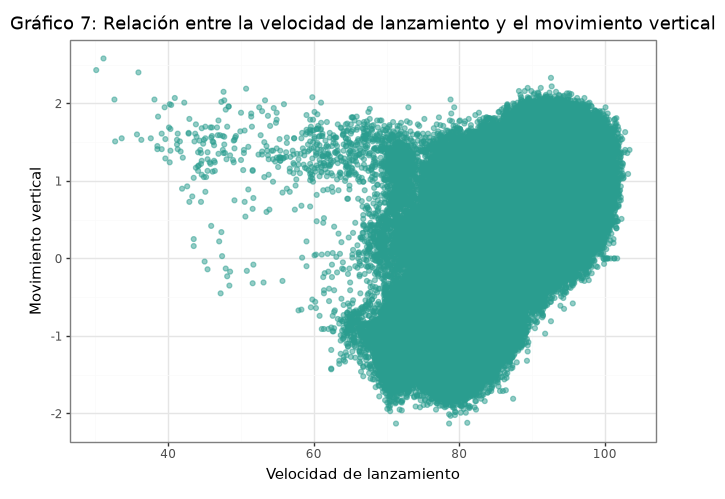

In [14]:
# Gráfico de la relación entre velocidad y movimiento vertical cambie según el tipo de pitcheo.
(
    ggplot(
        datos_entrenamiento
        .drop_nulls(["release_speed", "pfx_z"])
        .to_pandas(),
        aes(
            x="release_speed",
            y="pfx_z"
        )
    )
    + geom_point(
        alpha=0.5,
        color="#2A9D8F"
    )
    + theme_bw()
    + labs(
        title="Gráfico 7: Relación entre la velocidad de lanzamiento y el movimiento vertical",
        x="Velocidad de lanzamiento",
        y="Movimiento vertical"
    )
)

En el gráfico anterior se observa que, a medida que aumenta la velocidad de lanzamiento (`release_speed`), también tiende a incrementarse el movimiento vertical. Esto sugiere la existencia de una relación lineal positiva entre ambas variables, donde mayores velocidades de lanzamiento se asocian con valores más elevados de movimiento vertical. Este comportamiento resulta consistente con la correlación positiva alta identificada previamente en la matriz de correlaciones.

La relación entre la mano del pitcher y la posición del bateador resulta de interés, ya que puede influir en la dinámica del enfrentamiento entre ambos jugadores. Analizar la distribución conjunta de estas variables permite identificar posibles patrones de comportamiento y asociaciones que podrían aportar información relevante para comprender o predecir determinadas características de los lanzamientos.

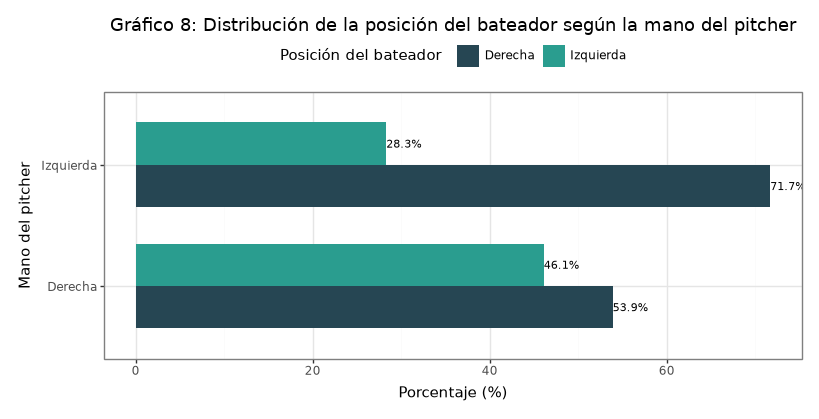

In [16]:
# Calculamos los porcentajes acumulados
df_prop = (
    datos_entrenamiento
    .group_by(["p_throws", "stand"])
    .len(name="count")
    .with_columns(
        (pl.col("count") / pl.col("count").sum().over("p_throws") * 100).alias("porcentaje")
    )
    .with_columns(
    pl.when(pl.col("p_throws") == "R")
      .then(pl.lit("Derecha"))
      .otherwise(pl.lit("Izquierda"))
      .alias("p_throws"),

    pl.when(pl.col("stand") == "R")
      .then(pl.lit("Derecha"))
      .otherwise(pl.lit("Izquierda"))
      .alias("stand")
    )
    .to_pandas()
)

# Gráfico de la distribucion de la posición del bateador según la mano del pitcher
(
    ggplot(df_prop, aes(x="p_throws", y="porcentaje", fill="stand"))
    + geom_col(position="dodge", width=0.7)
    + coord_flip()
    + geom_text(
        aes(label="porcentaje.round(1).astype(str) + '%'"),
        position=position_dodge(width=0.7),
        ha="left",
        size=8
    )
    + scale_fill_manual(
    values={
        "Izquierda": "#2A9D8F",
        "Derecha": "#264653"
    }
)
    + theme_bw()
    + theme(
        figure_size=(8, 4),
        legend_position="top"
    )
    + labs(
        title="Gráfico 8: Distribución de la posición del bateador según la mano del pitcher",
        x="Mano del pitcher",
        y="Porcentaje (%)",
        fill="Posición del bateador"
    )
)

En el gráfico anterior se observa que la posición del bateador presenta diferencias según la mano del pitcher. En los lanzamientos realizados por pitchers derechos, la distribución entre bateadores derechos e izquierdos resulta más equilibrada, aunque con una leve predominancia de bateadores derechos (53,9%) frente a los izquierdos (46,1%).

En cambio, cuando el pitcher es zurdo, se observa una mayor proporción de bateadores derechos (71,7%), mientras que los bateadores izquierdos representan el 28,3% de los casos. Esto indica una mayor presencia de enfrentamientos entre pitchers zurdos y bateadores derechos, posiblemente asociado a la estrategia habitual de los equipos de buscar ventajas de emparejamiento entre lanzador y bateador.

La posición del bateador puede influir en la elección del tipo de lanzamiento por parte del pitcher, ya que las características del enfrentamiento pueden afectar la estrategia utilizada durante el juego. Por este motivo, resulta interesante analizar la relación entre ambas variables para identificar posibles diferencias en la distribución de los tipos de lanzamiento según la posición del bateador.

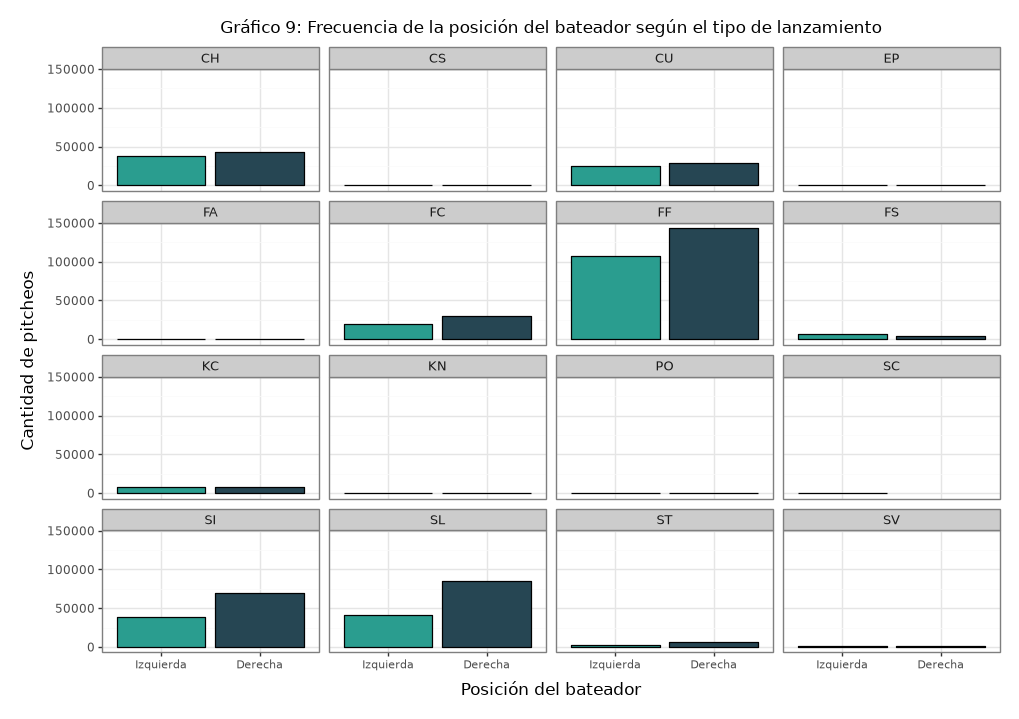

In [17]:
(
    ggplot(
        datos_entrenamiento.filter(
            pl.col("pitch_type").is_not_null() &
            pl.col("stand").is_not_null()
        ),
        aes(x="stand", fill="stand")
    )
    + geom_bar(color="black")
    + facet_wrap("~pitch_type", ncol=4)
    + scale_x_discrete(
        breaks=["L", "R"],
        labels=["Izquierda", "Derecha"]
    )
    + scale_fill_manual(
        values={
            "L": "#2A9D8F",
            "R": "#264653"
        }
    )
    + theme_bw()
    + theme(
        figure_size=(10, 7),
        strip_text=element_text(size=9),
        axis_text_x=element_text(size=8),
        title=element_text(size=12),
        legend_position="none"
    )
    + labs(
        title="Gráfico 9: Frecuencia de la posición del bateador según el tipo de lanzamiento",
        x="Posición del bateador",
        y="Cantidad de pitcheos"
    )
)

A partir del gráfico se observa que la cantidad de bateadores derechos es superior a la de bateadores izquierdos para los tipos de lanzamiento más frecuentes del conjunto de datos, como `FF`, `SL` y `SI`.

No obstante, para las demás categorías de `pitch_type`no se observan diferencias pronunciadas para la posición del bateador.

La velocidad de liberación constituye una característica clave para la caracterización de los lanzamientos. Analizar su distribución según el tipo de pitcheo permite identificar diferencias en los niveles de velocidad, variabilidad y posibles patrones asociados a cada categoría de lanzamiento.

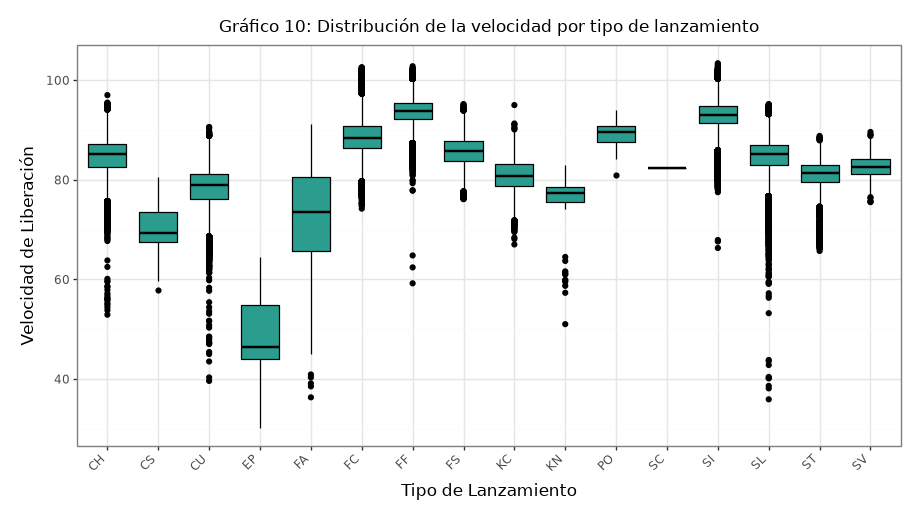

In [18]:
# Boxplot
(
    ggplot(datos_entrenamiento.filter(
            pl.col("pitch_type").is_not_null() &
            pl.col("release_speed").is_not_null()
        ), 
        aes(x="pitch_type", y="release_speed"))
    + geom_boxplot(
        fill="#2A9D8F",
        color="black",
        show_legend=False
    )
    + theme_bw()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(9, 5),
        title=element_text(size=12),
    )
    + labs(
        title="Gráfico 10: Distribución de la velocidad por tipo de lanzamiento",
        x="Tipo de Lanzamiento",
        y="Velocidad de Liberación",
    )
)

Se observan distribuciones de velocidad diferenciadas según el tipo de lanzamiento. Las mayores velocidades de lanzamiento se registran en `FF` y `SI`, mientras que `EP` y `CS` presentan las menores. Asimismo, la dispersión de la velocidad varía entre categorías: algunos lanzamientos, como `EP` y `FA`, presentan una mayor variabilidad, mientras que otros, como `FF` y `PO`, muestran velocidades más concentradas alrededor de la mediana.

El movimiento vertical de la pelota es una característica relevante para describir la trayectoria de los lanzamientos. Su análisis según el tipo de pitcheo permite identificar diferencias entre categorías y determinar si esta variable aporta información sobre las características de cada lanzamiento.

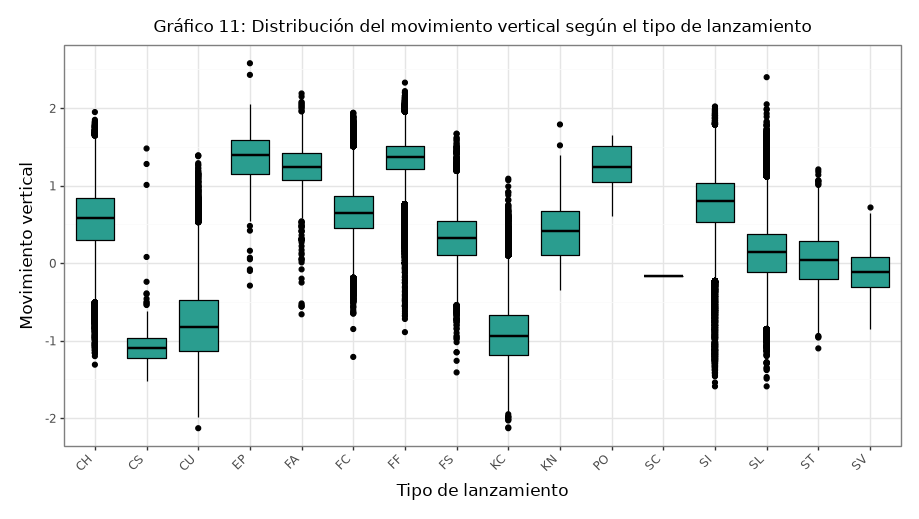

In [19]:
(
    ggplot(
        datos_entrenamiento.filter(
            pl.col("pitch_type").is_not_null() &
            pl.col("pfx_z").is_not_null()
        ),
        aes(x="pitch_type", y="pfx_z")
    )
    + geom_boxplot(
        fill="#2A9D8F",
        color="black",
        show_legend=False
    )
    + theme_bw()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(9, 5),
        title=element_text(size=12),
    )
    + labs(
        title="Gráfico 11: Distribución del movimiento vertical según el tipo de lanzamiento",
        x="Tipo de lanzamiento",
        y="Movimiento vertical"
    )
)

Se observan diferencias en el movimiento vertical entre los distintos tipos de lanzamiento. Algunas categorías de lanzamiento, como `EP`, `FF`, `FA` y `PO`, presentan movimientos medianos más altos, mientras que `CS`, `KC` y `CU` se caracterizan por valores más bajos o negativos. Por otro lado, si se pone énfasis en la variabilidad de los datos, no se observan diferencias tan notorias entre todos los tipos de lanzamiento, el único lanzamiento que tiene una mayor variabilidad es `CU`.

El movimiento horizontal es una característica relevante de los lanzamientos, ya que describe el desplazamiento lateral que experimenta la pelota durante su recorrido. Analizar su distribución según el tipo de lanzamiento permite identificar diferencias en el comportamiento de esta variable y determinar si aporta información útil para distinguir entre las distintas categorías de lanzamientos.

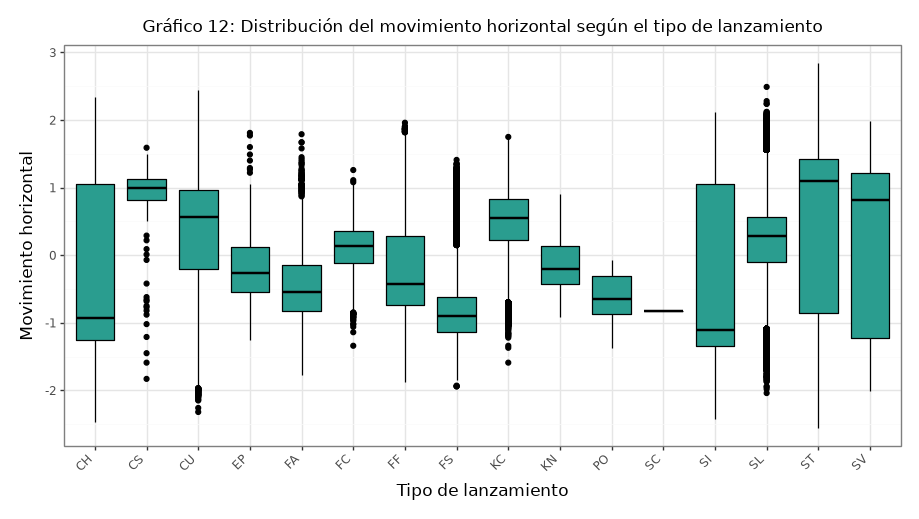

In [20]:
(
    ggplot(
        datos_entrenamiento.filter(
            pl.col("pitch_type").is_not_null() &
            pl.col("pfx_x").is_not_null()
        ),
        aes(x="pitch_type", y="pfx_x")
    )
    + geom_boxplot(
        fill="#2A9D8F",
        color="black",
        show_legend=False
    )
    + theme_bw()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(9, 5),
        title=element_text(size=12),
    )
    + labs(
        title="Gráfico 12: Distribución del movimiento horizontal según el tipo de lanzamiento",
        x="Tipo de lanzamiento",
        y="Movimiento horizontal"
    )
)

Se observan diferencias tanto en la magnitud como en la dispersión del movimiento horizontal según el tipo de lanzamiento. Mientras que categorías como `CS`, `ST` y `SV` presentan valores medianos positivos, otras como `CH`, `FS`, `PO` y `SI` muestran valores mayormente negativos. Además, algunos tipos de lanzamiento exhiben una amplia variabilidad en esta característica, como por ejemplo `CH`, `ST` y `SV`, lo que refleja comportamientos más heterogéneos. 

#### Construcción de variables
En el análisis exploratorio se observó que las variables `sz_top` y `sz_bot` presentan una correlación positiva elevada (r=0.78). Dado que ambas variables describen los límites de la zona de strike, se construye la variable `altura_zona`, definida como la diferencia entre `sz_top` y `sz_bot`. Esta nueva variable resume la información contenida en ambas medidas y permite reducir la redundancia entre predictores manteniendo una interpretación clara desde el punto de vista del juego.

Una aclaración importante es que la variable se crea tanto en el dataframe usado para entrenar a los modelos como en el que será utilizado para validar los datos.

In [21]:
datos_entrenamiento = datos_entrenamiento.with_columns(
    (pl.col("sz_top") - pl.col("sz_bot")).alias("altura_zona")
)

# Creamos las variables en datos_validacion
datos_validacion = datos_validacion.with_columns(
    (pl.col("sz_top") - pl.col("sz_bot")).alias("altura_zona")
)

Una vez creadas las variables a utilizar, se guarda el dataframe para poder continuar trabajando en las otras notebooks.

In [22]:
datos_entrenamiento.write_parquet(
    "../datos/temporada1.parquet"
)

datos_validacion.write_parquet(
    "../datos/temporada2.parquet"
)